In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

DATA_FILE = '../data/scenario_6_marina_features_50ms.csv'
df = pd.read_csv(DATA_FILE)

STEADY_THRESHOLD = 3000  # 3 seconds of buffer is healthy
DEPLETING_THRESHOLD = 700 # Below 0.7 seconds is a high risk of stalling

print("Dataset loaded successfully.")
df.info()

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660857 entries, 0 to 660856
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          660857 non-null  int64  
 1   video_id           660857 non-null  object 
 2   iteration          660857 non-null  object 
 3   packet_count       660857 non-null  int64  
 4   ps_sum             660857 non-null  int64  
 5   ps2_sum            660857 non-null  int64  
 6   ps3_sum            660857 non-null  int64  
 7   iat_sum            660857 non-null  float64
 8   iat2_sum           660857 non-null  float64
 9   iat3_sum           660857 non-null  float64
 10  buffer_level_ms    660857 non-null  int64  
 11  bwe                660857 non-null  int64  
 12  video_format_itag  660857 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 65.5+ MB


In [ ]:

def assign_buffer_state(bh_ms):
    if bh_ms < DEPLETING_THRESHOLD:
        return 'Depleting'
    elif bh_ms > STEADY_THRESHOLD:
        return 'Steady'
    else:
        return 'Filling'

df['buffer_state'] = df['buffer_level_ms'].apply(assign_buffer_state)

print("Class Distribution in the Dataset:")
print(df['buffer_state'].value_counts())

Class Distribution in the Dataset:
buffer_state
Filling      366274
Depleting    294583
Name: count, dtype: int64


In [ ]:
all_features = [
    'packet_count', 
    'ps_sum', 'ps2_sum', 'ps3_sum', 
    'iat_sum', 'iat2_sum', 'iat3_sum'
]
X = df[all_features]
y = df['buffer_state']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

dt_baseline = DecisionTreeClassifier(
    max_depth=5, 
    random_state=42, 
    class_weight='balanced' 
)
dt_baseline.fit(X_train, y_train)

print("--- Baseline Model (All Marina Features) Evaluation ---")
y_pred_baseline = dt_baseline.predict(X_test)
print(classification_report(y_test, y_pred_baseline))

--- Baseline Model (All Marina Features) Evaluation ---
              precision    recall  f1-score   support

   Depleting       0.53      0.33      0.41     73646
     Filling       0.59      0.76      0.66     91569

    accuracy                           0.57    165215
   macro avg       0.56      0.55      0.54    165215
weighted avg       0.56      0.57      0.55    165215




--- Feature Importances from Baseline Model ---
iat3_sum        0.336196
packet_count    0.303597
ps_sum          0.146943
iat2_sum        0.113639
ps3_sum         0.059521
ps2_sum         0.027125
iat_sum         0.012978
dtype: float64


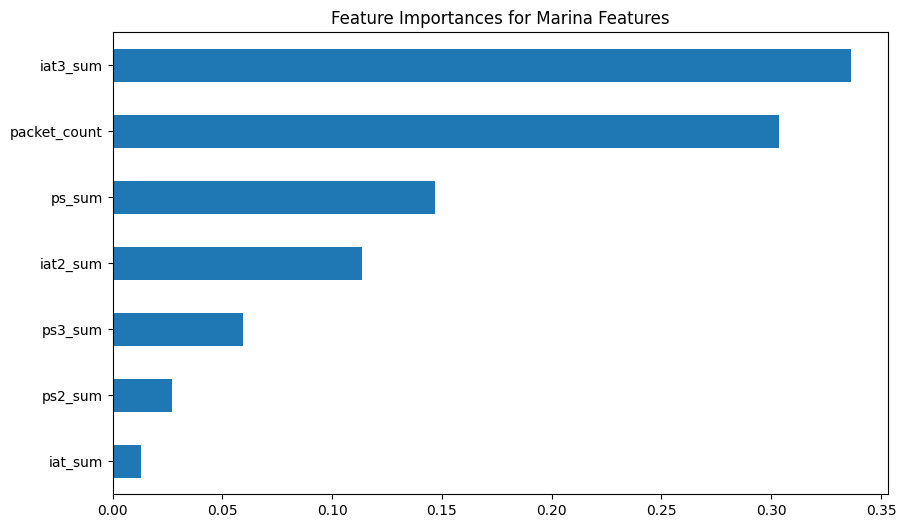

In [ ]:
importances = pd.Series(dt_baseline.feature_importances_, index=all_features)
importances.sort_values(ascending=False, inplace=True)

print("\n--- Feature Importances from Baseline Model ---")
print(importances)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', title='Feature Importances for Marina Features')
plt.show()

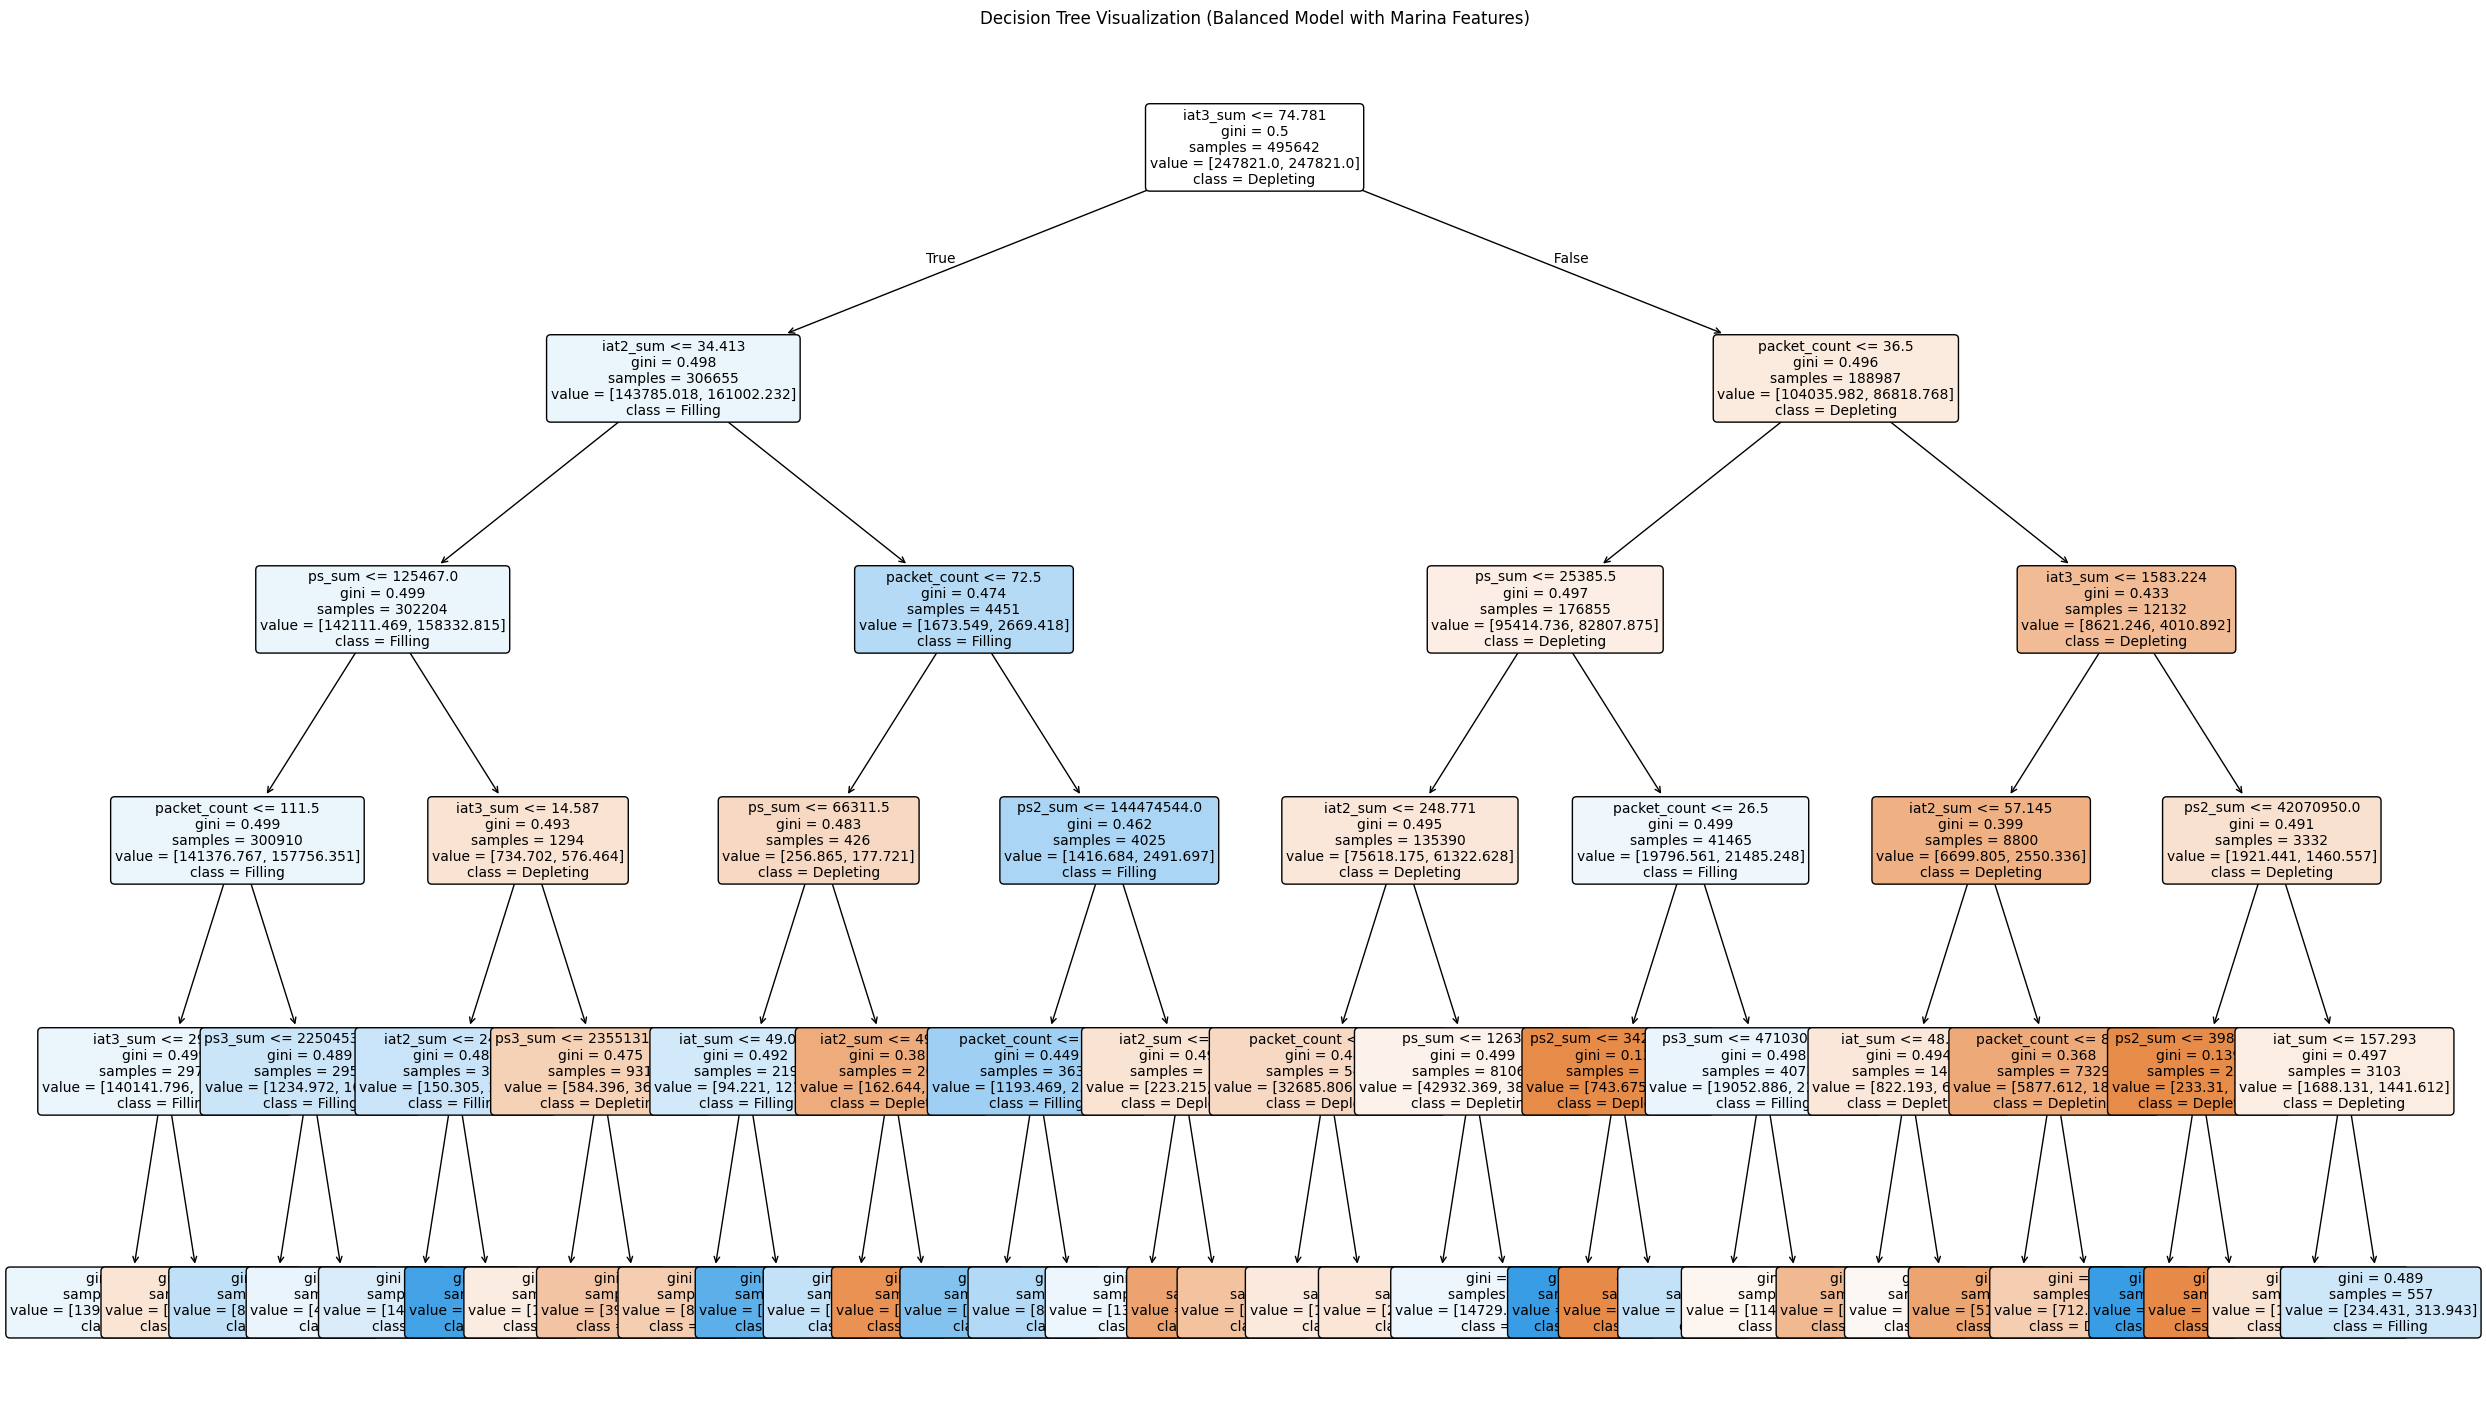

In [ ]:
plt.figure(figsize=(30, 18))
plot_tree(dt_baseline, 
          feature_names=all_features, 
          class_names=sorted(y.unique()),
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Visualization (Balanced Model with Marina Features)")
plt.show()

In [ ]:
feature_experiments = {
    "First_Moment_Only": ['packet_count', 'ps_sum', 'iat_sum'],
    "Packet_Size_Features_Only": ['packet_count', 'ps_sum', 'ps2_sum', 'ps3_sum'],
    "IAT_Features_Only": ['packet_count', 'iat_sum', 'iat2_sum', 'iat3_sum'],
    "All_Marina_Features": all_features
}

results = {}

print("\n\n--- Running Feature Set Experiments ---")

for name, features_to_test in feature_experiments.items():
    print(f"\n--- Testing: {name} ---")
    
    X_exp = df[features_to_test]
    y_exp = df['buffer_state']
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X_exp, y_exp, test_size=0.25, random_state=42, stratify=y_exp
    )
    
    model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
    model.fit(X_train_exp, y_train_exp)
    
    y_pred_exp = model.predict(X_test_exp)
    report = classification_report(y_test_exp, y_pred_exp, output_dict=True, zero_division=0)
    
    print(classification_report(y_test_exp, y_pred_exp, zero_division=0))
    
    if 'Depleting' in report:
        results[name] = report['Depleting']['recall']

print("\n\n--- Final Results: Recall for 'Depleting' State Across Experiments ---")
results_series = pd.Series(results)
results_series.sort_values(ascending=False, inplace=True)
print(results_series)



--- Running Feature Set Experiments ---

--- Testing: First_Moment_Only ---
              precision    recall  f1-score   support

   Depleting       0.52      0.35      0.42     73646
     Filling       0.59      0.74      0.66     91569

    accuracy                           0.57    165215
   macro avg       0.56      0.55      0.54    165215
weighted avg       0.56      0.57      0.55    165215


--- Testing: Packet_Size_Features_Only ---
              precision    recall  f1-score   support

   Depleting       0.52      0.35      0.42     73646
     Filling       0.59      0.74      0.66     91569

    accuracy                           0.57    165215
   macro avg       0.56      0.55      0.54    165215
weighted avg       0.56      0.57      0.55    165215


--- Testing: IAT_Features_Only ---
              precision    recall  f1-score   support

   Depleting       0.53      0.30      0.39     73646
     Filling       0.58      0.79      0.67     91569

    accuracy            